## EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
df = pd.read_csv("../data/processed/water_quality_cleaned.csv")
os.makedirs("../reports/figures", exist_ok=True)

print(f"Shape: {df.shape}")
df.head()

Shape: (739148, 23)


,pH,Iron,Nitrate,Chloride,Lead,Zinc,Color,Turbidity,Fluoride,Copper,...,Chlorine,Manganese,Total Dissolved Solids,Source,Water Temperature,Air Temperature,Month,Day,Time of Day,Target
0,6.917863,8.050000e-05,3.734167,227.029851,7.850000e-94,1.245317,Faint Yellow,0.019007,0.622874,0.437835,...,3.292038,8.020000e-07,284.641984,Lake,15.348981,71.220586,11.0,26.0,16.0,0
1,5.443762,2.010586e-02,3.816994,230.995630,5.290000e-76,0.528280,Light Yellow,0.319956,0.423423,0.431588,...,3.560224,7.007989e-02,570.054094,River,11.643467,44.891330,1.0,31.0,8.0,0
2,8.091909,2.167128e-03,9.925788,186.540872,4.170000e-132,3.807511,Light Yellow,0.004867,0.222912,0.616574,...,3.177849,3.296139e-03,168.075545,Spring,15.249416,69.336671,6.0,29.0,7.0,0
3,7.258203,6.110000e-09,9.261676,182.242341,4.400000e-224,0.416478,Colorless,0.047803,1.016196,0.298093,...,2.325094,6.020000e-16,214.553104,River,15.891905,61.139140,4.0,11.0,4.0,0
4,7.100650,3.019038e-03,3.620641,157.043934,6.460000e-148,0.112994,Colorless,0.050613,0.842107,0.391602,...,2.284971,8.840000e-07,113.909077,River,11.899376,14.010268,4.0,7.0,12.0,0


#### Missing value check

In [3]:
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "✅ No missing values")

✅ No missing values


#### Target distribution

In [4]:
print(df["Target"].value_counts())
print(df["Target"].value_counts(normalize=True).round(3))

Target
0    569004
1    170144
Name: count, dtype: int64
Target
0    0.77
1    0.23
Name: proportion, dtype: float64


In [5]:
print("The comparision of mean values of target：")
key_cols = ["pH", "Iron", "Turbidity", "Fluoride", "Copper",
            "Lead", "Nitrate", "Chloride", "Odor", "Manganese"]
print(df.groupby("Target")[key_cols].mean().T.round(4))

The comparision of mean values of target：
Target            0         1
pH           7.4644    7.3970
Iron         0.0707    0.2596
Turbidity    0.3716    0.8598
Fluoride     0.8649    1.1973
Copper       0.4243    0.7279
Lead         0.0006    0.0037
Nitrate      5.7822    7.0688
Chloride   174.2510  207.4217
Odor         1.6807    2.0865
Manganese    0.0461    0.2537


All pollutant indicators are significantly higher when Target = 1, and the conclusion is clear:

Target = 1 → Unsafe (problematic water quality)

Target = 0 → Safe (normal water quality)

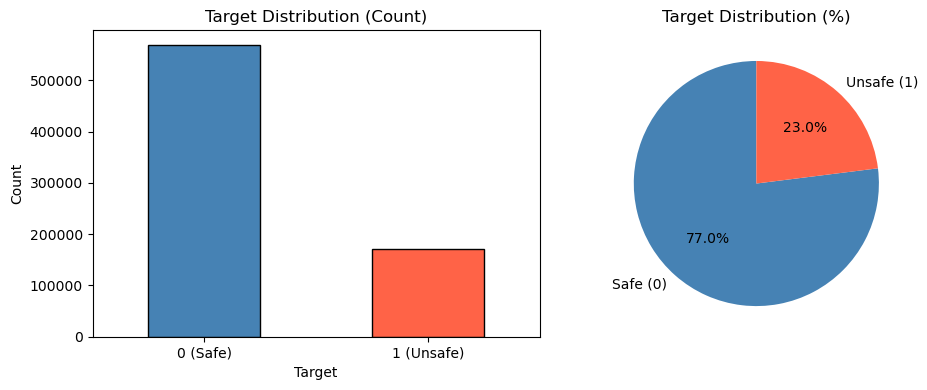

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Count plot
df["Target"].value_counts().plot(kind="bar", ax=axes[0], color=["steelblue", "tomato"], edgecolor="black")
axes[0].set_title("Target Distribution (Count)")
axes[0].set_xlabel("Target")
axes[0].set_ylabel("Count")
axes[0].set_xticklabels(["0 (Safe)", "1 (Unsafe)"], rotation=0)

# Pie chart
df["Target"].value_counts().plot(kind="pie", ax=axes[1], labels=["Safe (0)", "Unsafe (1)"],
                                  autopct="%1.1f%%", colors=["steelblue", "tomato"], startangle=90)
axes[1].set_ylabel("")
axes[1].set_title("Target Distribution (%)")

plt.tight_layout()
plt.savefig("../reports/figures/target_distribution.png", dpi=150)
plt.show()

In [7]:
# Define the numerical and categorical parameters
numerical_cols = ["pH", "Iron", "Nitrate", "Chloride", "Lead", "Zinc",
                  "Turbidity", "Fluoride", "Copper", "Odor", "Sulfate",
                  "Conductivity", "Chlorine", "Manganese", "Total Dissolved Solids",
                  "Water Temperature", "Air Temperature", "Day", "Time of Day", "Month"]

categorical_cols = ["Color", "Source"]

print(f"Numerical features: {len(numerical_cols)}")
print(f"Categorical features: {len(categorical_cols)}")

Numerical features: 20
Categorical features: 2


In [8]:
# Description statistics
df[numerical_cols].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
pH,739148.0,7.449,0.848,2.058,6.915,7.453,8.001,12.892
Iron,739148.0,0.114,0.443,0.000,0.000,0.002,0.050,15.749
Nitrate,739148.0,6.078,3.131,0.286,3.950,5.566,7.587,69.731
Chloride,739148.0,181.887,65.783,29.413,137.423,174.749,215.701,1430.549
Lead,739148.0,0.001,0.030,0.000,0.000,0.000,0.000,3.504
Zinc,739148.0,1.529,1.504,0.000,0.414,1.075,2.216,28.369
Turbidity,739148.0,0.484,0.864,0.000,0.037,0.200,0.592,19.296
Fluoride,739148.0,0.941,0.793,0.000,0.370,0.766,1.318,12.852
Copper,739148.0,0.494,0.567,0.000,0.126,0.339,0.679,10.717
Odor,739148.0,1.774,1.051,0.011,0.879,1.746,2.613,4.142


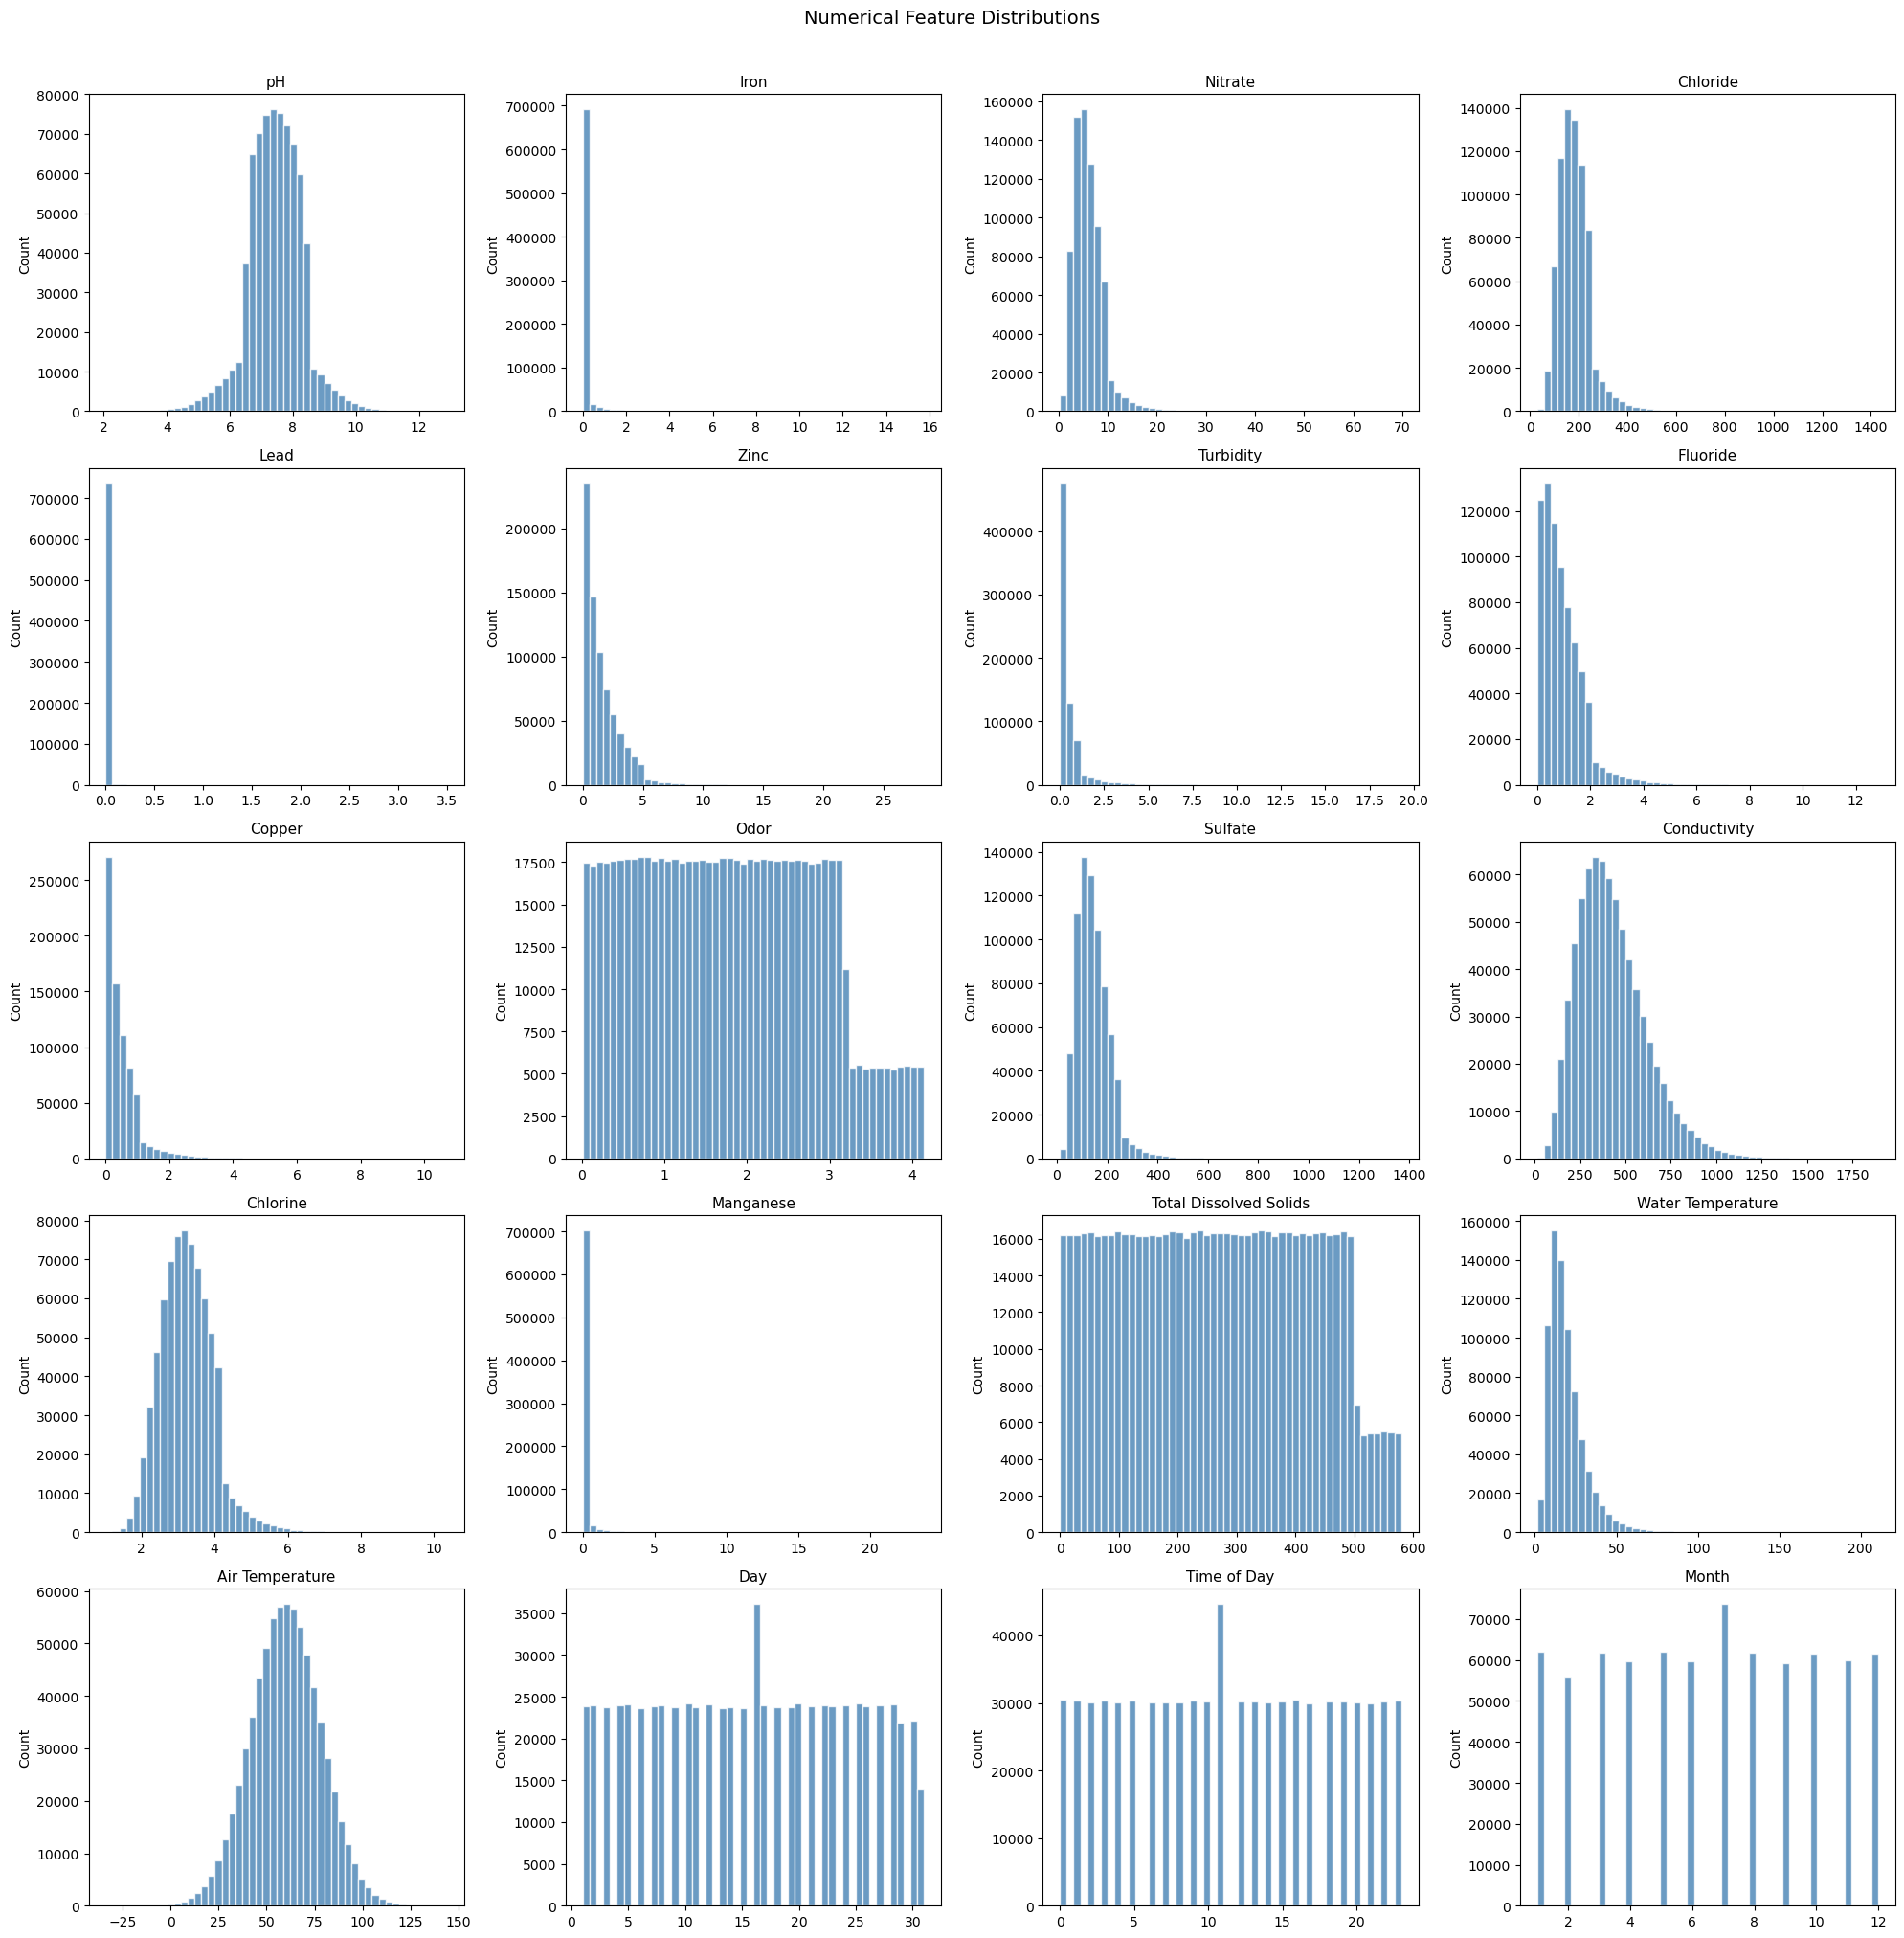

In [9]:
# Plotting distributions for all numerical variables (Histogram)
fig, axes = plt.subplots(5, 4, figsize=(20, 20))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col], bins=50, color="steelblue", edgecolor="white", alpha=0.8)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")

# Hide extra subplots
for j in range(len(numerical_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Numerical Feature Distributions", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("../reports/figures/numerical_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

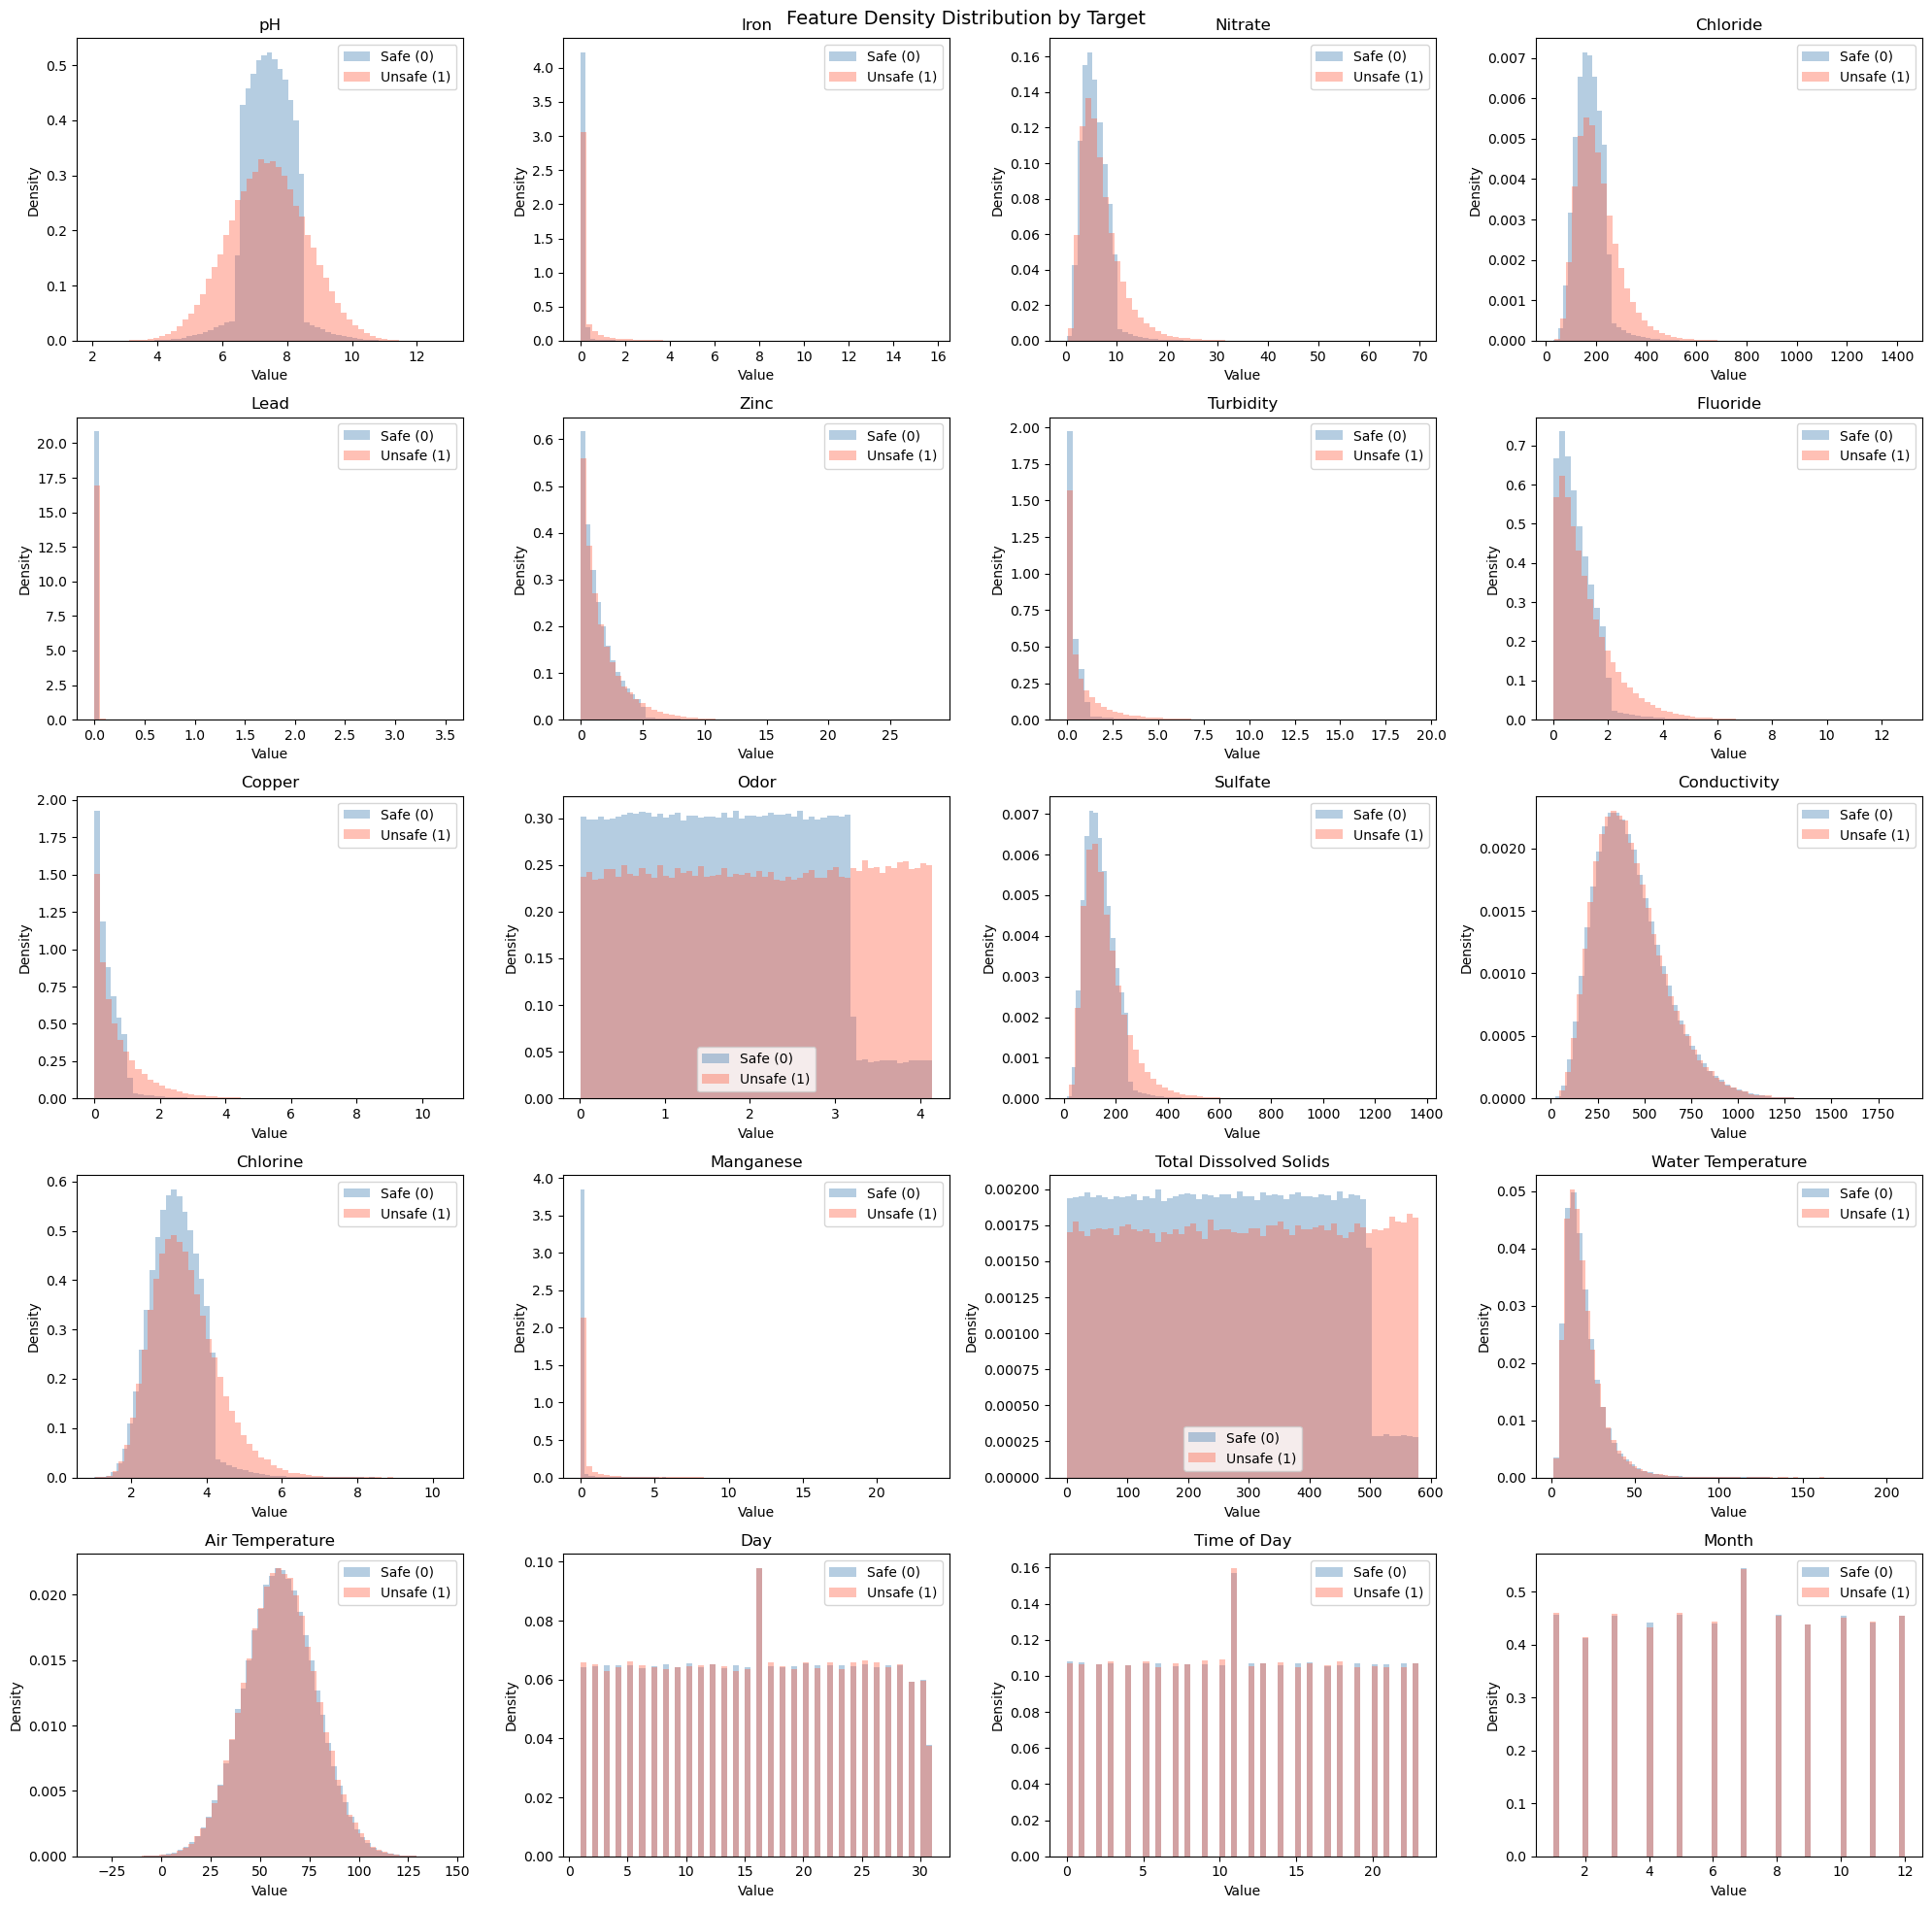

In [10]:
# The Histogram by different targets, can witness the influence of parameters directly.
safe   = df[df['Target'] == 0]
unsafe = df[df['Target'] == 1]
fig, axes = plt.subplots(5, 4, figsize=(20, 20))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(safe[col],   bins=60, density=True, histtype='stepfilled',
                 alpha=0.4, color='steelblue', label='Safe (0)')
    axes[i].hist(unsafe[col], bins=60, density=True, histtype='stepfilled',
                 alpha=0.4, color='tomato',    label='Unsafe (1)')
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')
    axes[i].legend()

plt.suptitle('Feature Density Distribution by Target', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/figures/kde_by_target.png', dpi=150, bbox_inches='tight')
plt.show()

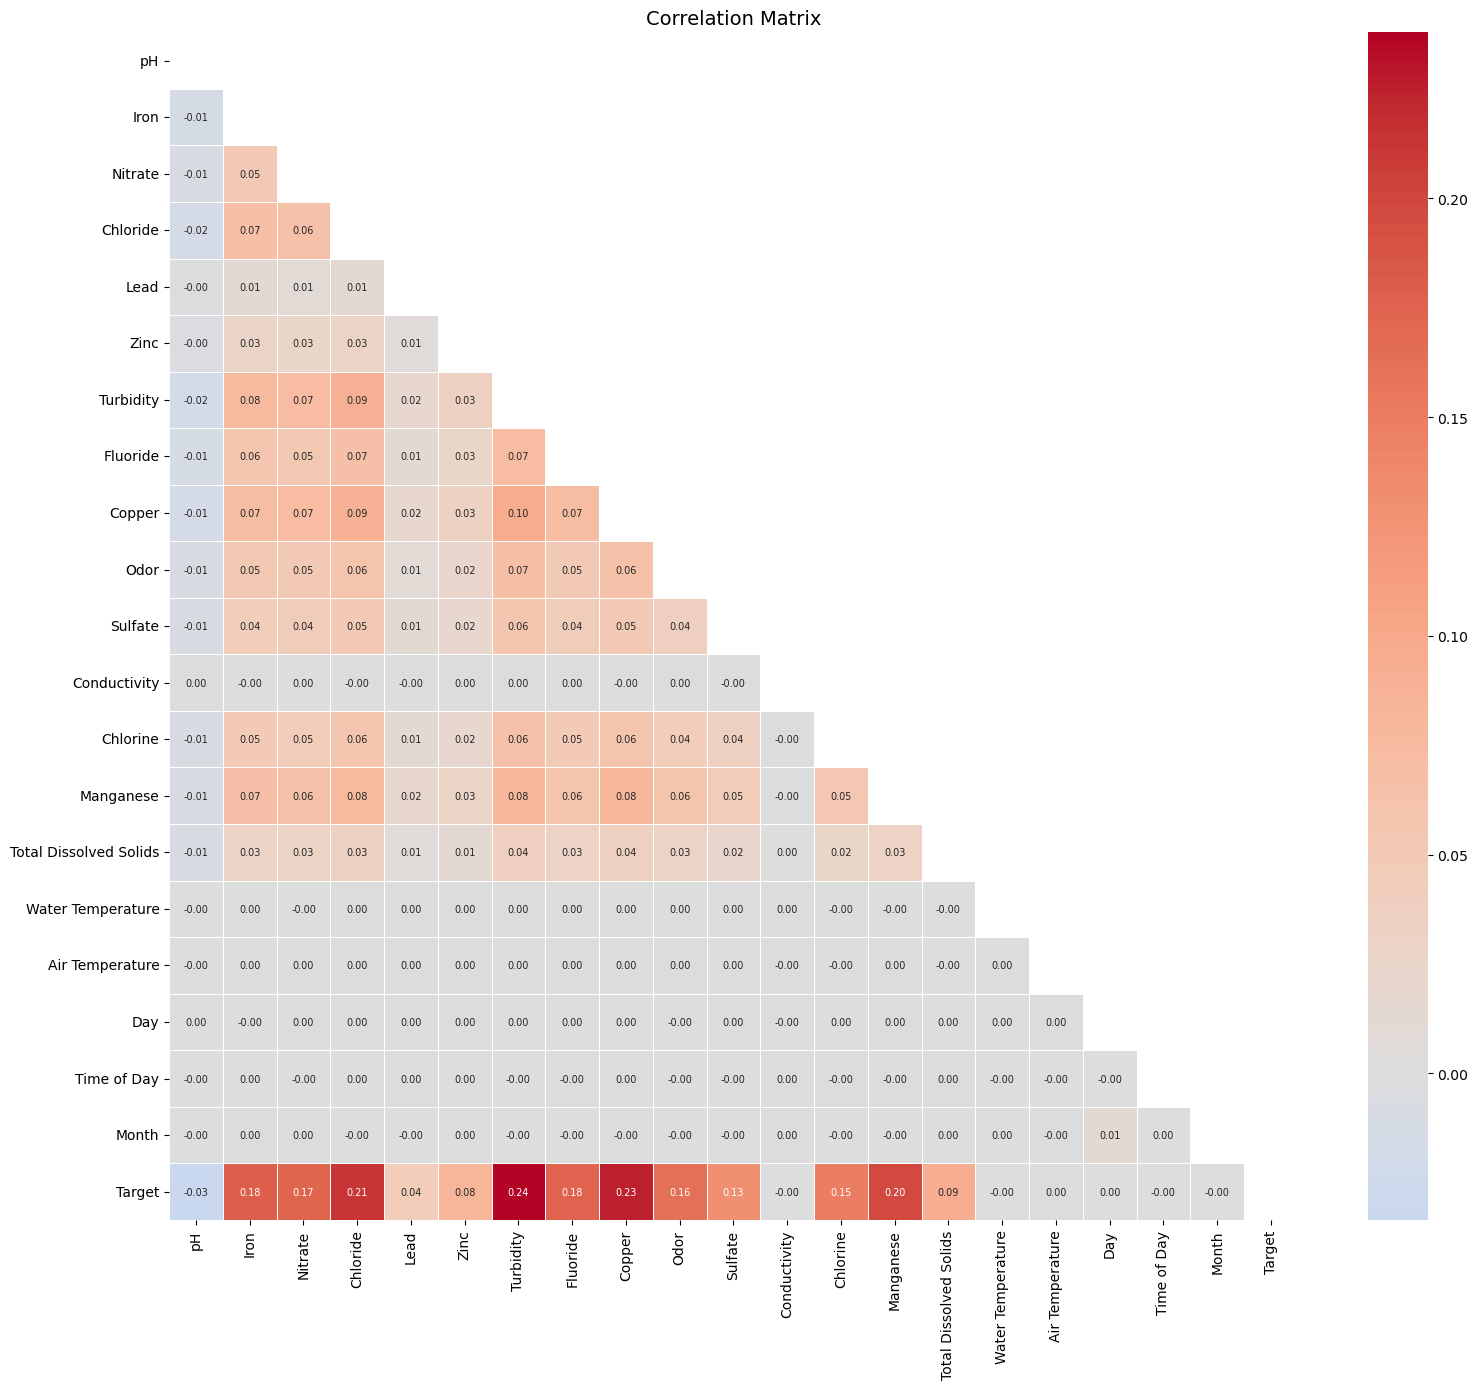

In [11]:
# Correlation Matrix
corr_matrix = df[numerical_cols + ["Target"]].corr()

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=ax, annot_kws={"size": 7}, linewidths=0.5)
ax.set_title("Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.savefig("../reports/figures/correlation_matrix.png", dpi=150)
plt.show()

In [12]:
# Ranking list of correlation with Target
target_corr = df[numerical_cols].corrwith(df["Target"]).abs().sort_values(ascending=False)

print("Feature Correlation with Target (absolute value):")
print(target_corr.round(4))

Feature Correlation with Target (absolute value):
Turbidity                 0.2380
Copper                    0.2256
Chloride                  0.2123
Manganese                 0.1979
Iron                      0.1794
Fluoride                  0.1764
Nitrate                   0.1730
Odor                      0.1625
Chlorine                  0.1490
Sulfate                   0.1318
Total Dissolved Solids    0.0933
Zinc                      0.0834
Lead                      0.0440
pH                        0.0335
Air Temperature           0.0032
Time of Day               0.0013
Conductivity              0.0013
Month                     0.0004
Day                       0.0004
Water Temperature         0.0000
dtype: float64


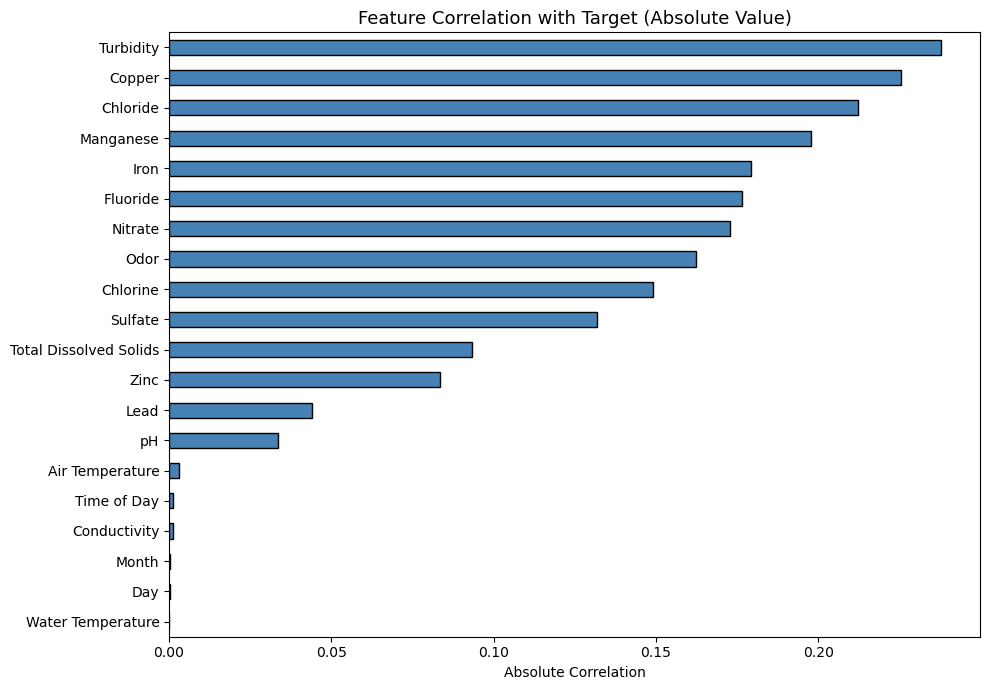

In [13]:
# Visualization of relevance to Target
fig, ax = plt.subplots(figsize=(10, 7))
target_corr.plot(kind="barh", ax=ax, color="steelblue", edgecolor="black")
ax.set_title("Feature Correlation with Target (Absolute Value)", fontsize=13)
ax.set_xlabel("Absolute Correlation")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../reports/figures/feature_target_correlation.png", dpi=150)
plt.show()

In [14]:
time_cols = ["Month", "Day", "Time of Day"]
time_corr = df[time_cols].corrwith(df["Target"]).abs()

print("Time variables correlation with Target:")
print(time_corr.round(4))

Time variables correlation with Target:
Month          0.0004
Day            0.0004
Time of Day    0.0013
dtype: float64


The three time variables all have correlations close to 0 with the Target, which shows that sampling time doesn't really contribute to water quality prediction. The timestamps are used for random sampling records, not to track systematic changes in water quality.

#### Color Distribution

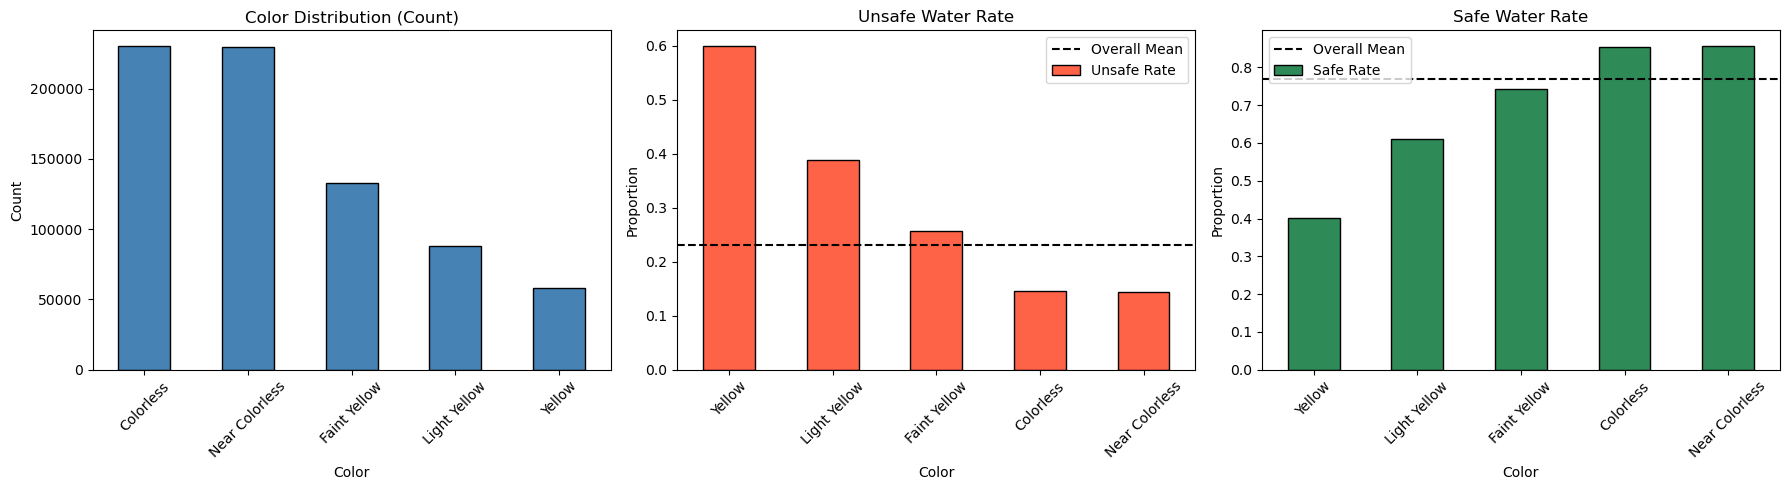

In [15]:
color_stats = df.groupby("Color")["Target"].agg(['mean', lambda x: 1 - x.mean()])
color_stats.columns = ['Unsafe Rate', 'Safe Rate']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Overall
df["Color"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="black")
axes[0].set_title("Color Distribution (Count)")
axes[0].set_xlabel("Color")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

# Unsafe Rate
color_stats['Unsafe Rate'].sort_values(ascending=False).plot(kind="bar", ax=axes[1], color="tomato", edgecolor="black")
axes[1].set_title("Unsafe Water Rate")
axes[1].set_ylabel("Proportion")
axes[1].axhline(y=df["Target"].mean(), color="black", linestyle="--", label="Overall Mean")
axes[1].legend()
axes[1].tick_params(axis="x", rotation=45)

# Safe Rate

color_stats['Safe Rate'].sort_values(ascending=True).plot(kind="bar", ax=axes[2], color="seagreen", edgecolor="black")
axes[2].set_title("Safe Water Rate")
axes[2].set_ylabel("Proportion")
axes[2].axhline(y=1 - df["Target"].mean(), color="black", linestyle="--", label="Overall Mean")
axes[2].legend()
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

#### Source Distribution

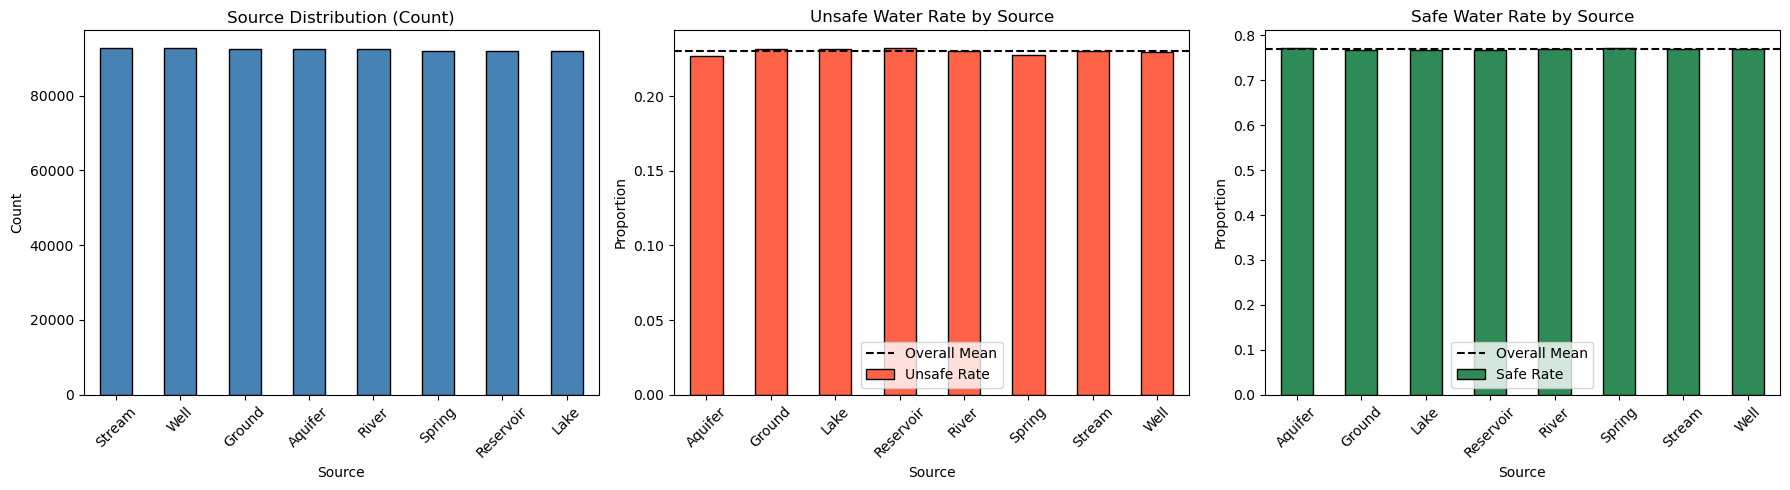

In [16]:
# Source analysis
source_stats = df.groupby("Source")["Target"].agg(['mean', lambda x: 1 - x.mean()])
source_stats.columns = ['Unsafe Rate', 'Safe Rate']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Overall Distribution
df["Source"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="black")
axes[0].set_title("Source Distribution (Count)")
axes[0].set_xlabel("Source")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

# Unsafe Rate
source_stats['Unsafe Rate'].plot(kind="bar", ax=axes[1], color="tomato", edgecolor="black")
axes[1].set_title("Unsafe Water Rate by Source")
axes[1].set_xlabel("Source")
axes[1].set_ylabel("Proportion")
axes[1].axhline(y=df["Target"].mean(), color="black", linestyle="--", label="Overall Mean")
axes[1].legend()
axes[1].tick_params(axis="x", rotation=45)

# Safe Rate
source_stats['Safe Rate'].plot(kind="bar", ax=axes[2], color="seagreen", edgecolor="black")
axes[2].set_title("Safe Water Rate by Source")
axes[2].set_xlabel("Source")
axes[2].set_ylabel("Proportion")
axes[2].axhline(y=1 - df["Target"].mean(), color="black", linestyle="--", label="Overall Mean")
axes[2].legend()
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("../reports/figures/source_analysis.png", dpi=150)
plt.show()

The 8 types of water source sampling are very balanced, which shows that the dataset is well-designed and there’s no sampling bias.

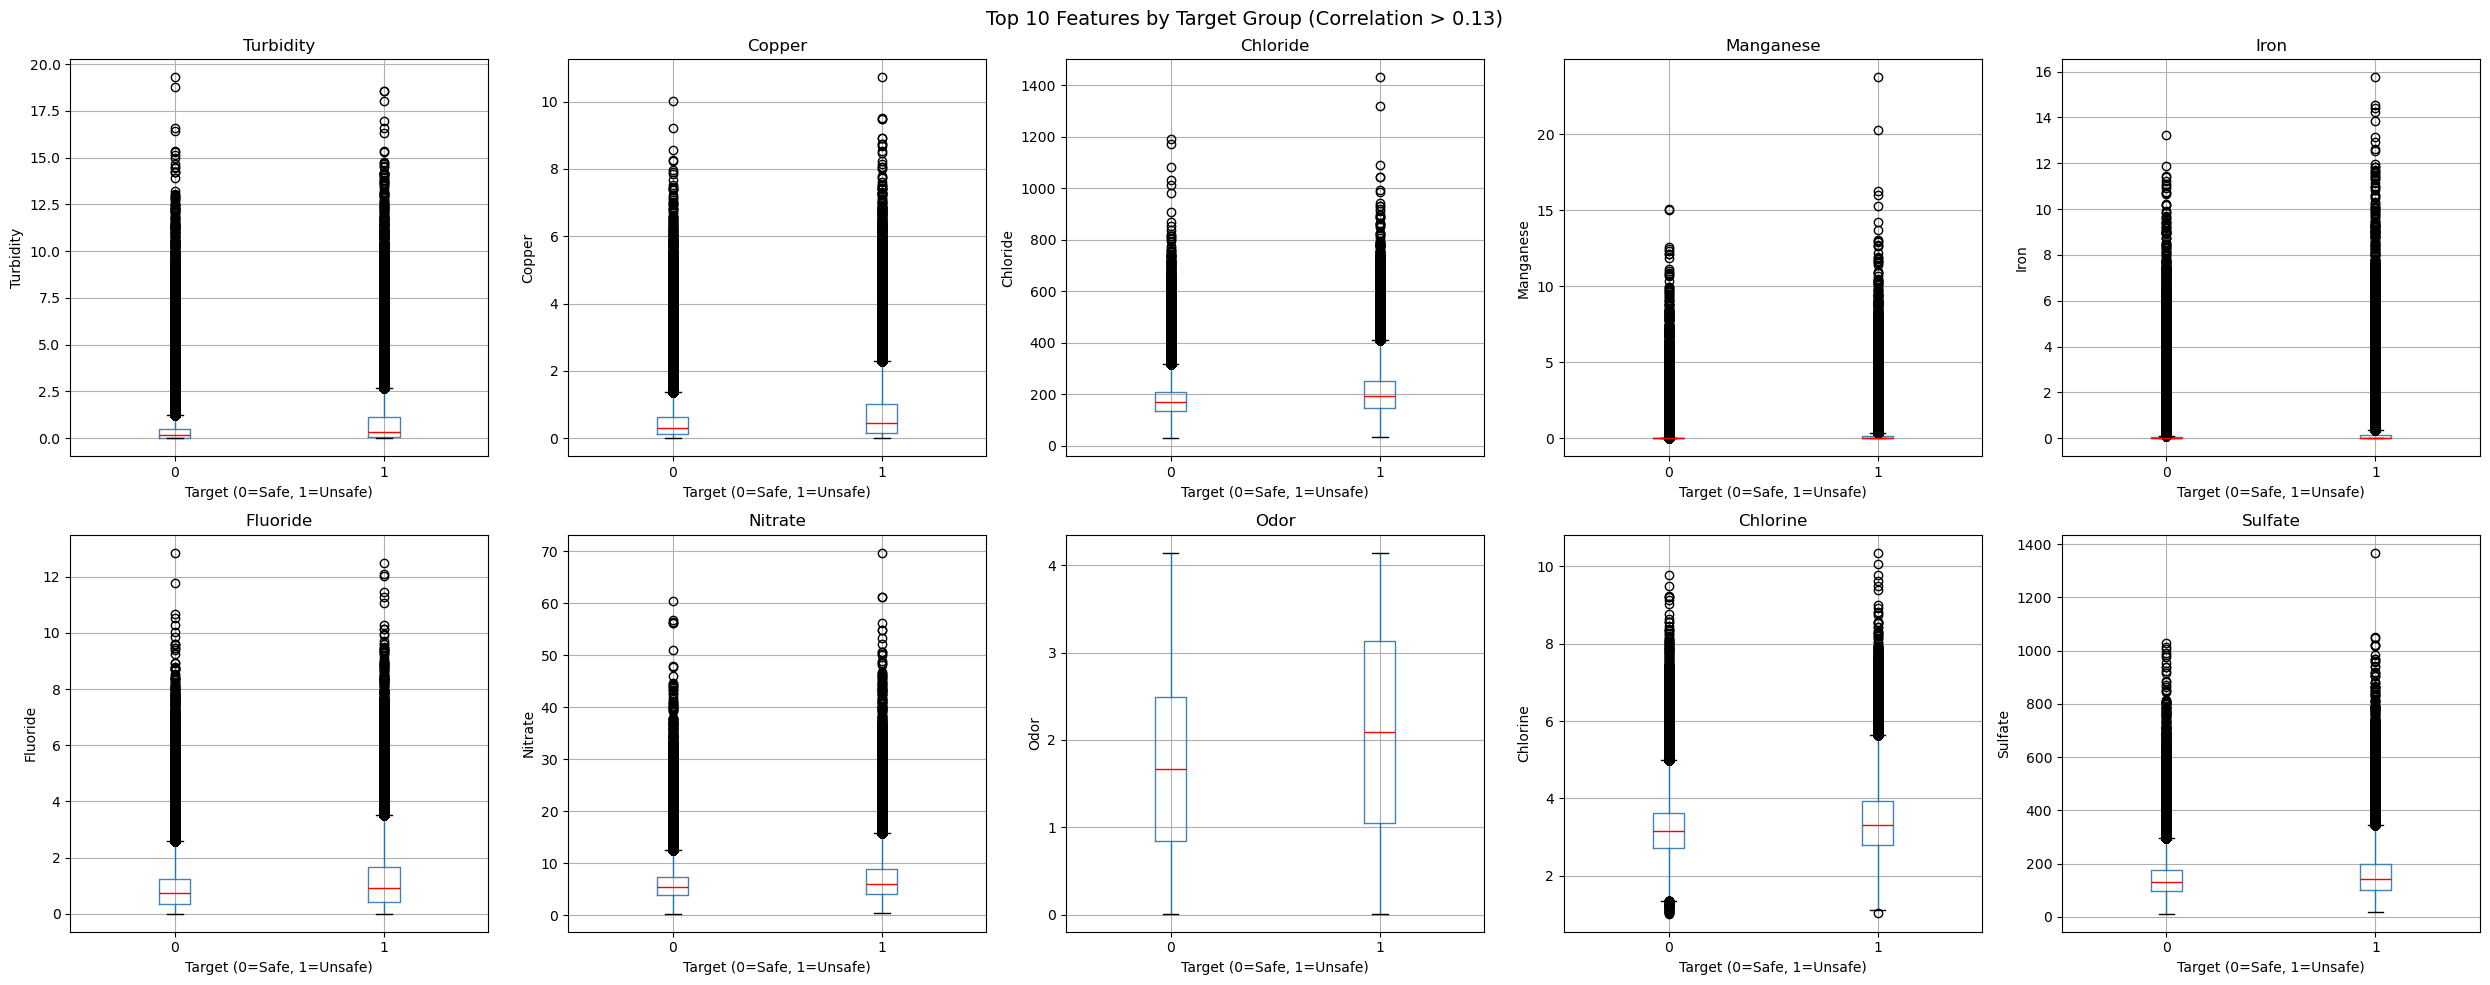

In [17]:
# Boxplot of Top 10 Features (sorted by correlation, above 0.13)
top10 = ["Turbidity", "Copper", "Chloride", "Manganese",
         "Iron", "Fluoride", "Nitrate", "Odor", "Chlorine", "Sulfate"]

fig, axes = plt.subplots(2, 5, figsize=(25, 10))
axes = axes.flatten()

for i, col in enumerate(top10):
    df.boxplot(column=col, by="Target", ax=axes[i],
               boxprops=dict(color="steelblue"),
               medianprops=dict(color="red"))
    axes[i].set_title(col)
    axes[i].set_xlabel("Target (0=Safe, 1=Unsafe)")
    axes[i].set_ylabel(col)

plt.suptitle("Top 10 Features by Target Group (Correlation > 0.13)", fontsize=14)
plt.tight_layout()
plt.savefig("../reports/figures/top10_boxplot.png", dpi=150)
plt.show()

### EDA Summary

In [18]:
print(f"Total samples after cleaning : {len(df):,}")
print(f"Safe water   (Target=0)      : {(df['Target']==0).sum():,} ({(df['Target']==0).mean():.1%})")
print(f"Unsafe water (Target=1)      : {(df['Target']==1).sum():,} ({(df['Target']==1).mean():.1%})")
print()
print("Top 5 predictors (by correlation):")
for i, (feat, val) in enumerate(target_corr.head(5).items(), 1):
    print(f"  {i}. {feat:<25} {val:.4f}")


Total samples after cleaning : 739,148
Safe water   (Target=0)      : 569,004 (77.0%)
Unsafe water (Target=1)      : 170,144 (23.0%)

Top 5 predictors (by correlation):
  1. Turbidity                 0.2380
  2. Copper                    0.2256
  3. Chloride                  0.2123
  4. Manganese                 0.1979
  5. Iron                      0.1794


### 中文发现
1. Dataset After Cleaning

清洗后保留 739,148 行（70.5%）
Safe (0): 569,004 行（77.0%）
Unsafe (1): 170,144 行（23.0%）
中度不平衡，但 drop 操作未改变原始比例，清洗过程随机无偏

2. Target Variable Confirmed
通过各污染物均值对比确认：

Target = 0 → Safe water
Target = 1 → Unsafe water

3. Feature Correlation with Target
相关性在 0.13 处存在自然断点：
强相关（>0.13）— Top 10：

Turbidity (0.238) > Copper (0.226) > Chloride (0.212) > Manganese (0.199) > Iron (0.179) > Fluoride (0.176) > Nitrate (0.173) > Odor (0.163) > Chlorine (0.149) > Sulfate (0.132)
弱相关（0.03–0.09）： Total Dissolved Solids、Zinc、Lead、pH
几乎无关（<0.005）： Air Temperature、Conductivity、Time of Day、Month、Day、Water Temperature

4. No Single Dominant Predictor
最高相关性仅 0.238，水质由多因素共同决定，无单一主导变量

5. pH 的反直觉发现
pH 相关性仅 0.034，远低于预期，尽管是最常见水质指标，在本数据集中预测能力极弱

6. Time Variables — No Predictive Value
Month、Day、Time of Day 相关性均 < 0.002，确认为采样记录而非预测因子

8. Color — 强烈影响 Unsafe Rate
颜色与水质有显著关联：

Yellow: ~60% Unsafe（远高于均值 23%）
Light Yellow: ~39% Unsafe
Faint Yellow: ~26% Unsafe（接近均值）
Colorless: ~15% Unsafe
Near Colorless: ~15% Unsafe

水的颜色越深（越黄），Unsafe 概率越高，符合物理直觉

8. Source — 几乎无影响
8 种水源的：

采样量完全均衡（每种约 92,000 行），无采样偏差
Unsafe Rate 几乎完全一致，所有水源的 Unsafe 比例都紧贴均值（约 23%），无明显差异

### Key EDA Findings

Target variable confirmed:
* 0 → Safe water (77.0%)
* 1 → Unsafe water (23.0%)

Top 10 predictors (correlation > 0.13):
1. Turbidity       0.238
2. Copper          0.226
3. Chloride        0.212
4. Manganese       0.199
5. Iron            0.179
6. Fluoride        0.176
7. Nitrate         0.173
8. Odor            0.163
9. Chlorine        0.149
10. Sulfate        0.132

Important observations:
* No single dominant predictor (max 0.238).
* Water quality is determined by multiple factors.
* Heavy metals and turbidity are the strongest predictors.
* pH has surprisingly weak correlation (0.034).
* Color is strongly associated with unsafe water rate:
  Yellow (60%) >> Light Yellow (39%) > overall mean (23%)
  > Faint Yellow (26%) > Colorless/Near Colorless (15%).
* Source has no predictive value; all 8 sources show
  identical unsafe rates (~23%), confirming unbiased sampling.
* Time variables (Month/Day/Time of Day) show near-zero
  correlation, confirming they are sampling records only.


### Outlier Detection — IQR Method

The IQR (Inter Quartile Range) approach is the most commonly used method for outlier detection.
Upper and lower bounds are defined as:
- **Upper = Q3 + 1.5 × IQR**
- **Lower = Q1 – 1.5 × IQR**

This quantifies how many extreme values exist in each feature, which informs preprocessing decisions.

In [19]:
# Outlier detection using IQR method (Ch.5 — IQR Statistical Approach)
# Features selected: same numerical_cols defined earlier in this notebook
outlier_cols = ["pH", "Iron", "Nitrate", "Chloride", "Lead", "Zinc",
                "Turbidity", "Fluoride", "Copper", "Odor", "Sulfate",
                "Conductivity", "Chlorine", "Manganese", "Total Dissolved Solids",
                "Water Temperature", "Air Temperature"]

outlier_summary = []

for col in outlier_cols:
    Q1 = np.percentile(df[col], 25, interpolation='midpoint')
    Q3 = np.percentile(df[col], 75, interpolation='midpoint')
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    lower = Q1 - 1.5 * IQR

    n_upper = (df[col] > upper).sum()
    n_lower = (df[col] < lower).sum()
    n_total = n_upper + n_lower
    pct = round(n_total / len(df) * 100, 2)

    outlier_summary.append({
        'Feature'      : col,
        'Q1'           : round(Q1, 3),
        'Q3'           : round(Q3, 3),
        'IQR'          : round(IQR, 3),
        'Lower Bound'  : round(lower, 3),
        'Upper Bound'  : round(upper, 3),
        'Above Upper'  : int(n_upper),
        'Below Lower'  : int(n_lower),
        'Total Outliers': int(n_total),
        'Outlier %'    : pct
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values('Outlier %', ascending=False)
outlier_df

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Above Upper,Below Lower,Total Outliers,Outlier %
4,Lead,0.000,0.000,0.000,-0.000,0.000,182185,0,182185,24.65
1,Iron,0.000,0.050,0.050,-0.075,0.124,118443,0,118443,16.02
13,Manganese,0.000,0.014,0.014,-0.021,0.034,118338,0,118338,16.01
6,Turbidity,0.037,0.592,0.555,-0.796,1.425,51880,0,51880,7.02
8,Copper,0.126,0.679,0.553,-0.704,1.508,36118,0,36118,4.89
15,Water Temperature,11.351,23.854,12.503,-7.403,42.607,31162,0,31162,4.22
7,Fluoride,0.370,1.318,0.948,-1.051,2.740,23318,0,23318,3.15
2,Nitrate,3.950,7.587,3.637,-1.506,13.043,21920,0,21920,2.97
3,Chloride,137.423,215.701,78.278,20.006,333.119,21731,0,21731,2.94
5,Zinc,0.414,2.216,1.802,-2.290,4.920,20842,0,20842,2.82


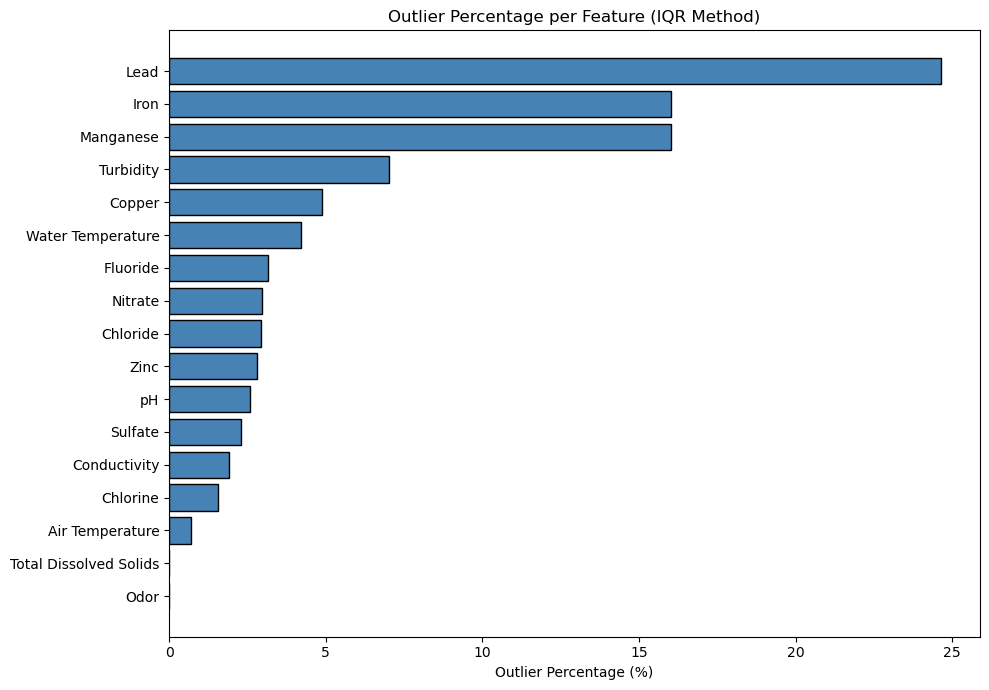

In [20]:
# Visualise outlier percentage per feature using a horizontal bar chart
# Following the bar chart style shown in Ch.4 slides
fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(outlier_df['Feature'], outlier_df['Outlier %'],
        color='steelblue', edgecolor='black')

ax.set_xlabel('Outlier Percentage (%)')
ax.set_title('Outlier Percentage per Feature (IQR Method)')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../reports/figures/outlier_iqr.png', dpi=150)
plt.show()

### Outlier Detection — Z-Score Method

Z-Score measures how many standard deviations a data point is from the mean:
**z = (x − mean) / std**

A threshold of **3.0** is used (covering 99.7% of data under Gaussian distribution).
Comparing IQR and Z-Score results shows whether outliers are consistent across both methods.

In [21]:
# Outlier detection using Z-Score method (Ch.5 — Z-Score Statistical Approach)
# scipy.stats is used only for zscore(), consistent with the lecture slides
from scipy import stats

threshold = 3

z_scores = np.abs(stats.zscore(df[outlier_cols]))

zscore_outliers = (z_scores > threshold).sum(axis=0)
zscore_pct      = (zscore_outliers / len(df) * 100).round(2)

zscore_df = pd.DataFrame({
    'Feature'         : outlier_cols,
    'Z-Score Outliers': zscore_outliers,
    'Outlier %'       : zscore_pct
}).sort_values('Outlier %', ascending=False).reset_index(drop=True)

print(f"Z-Score method (threshold = {threshold}) — outlier count per feature:")
zscore_df

Z-Score method (threshold = 3) — outlier count per feature:


,Feature,Z-Score Outliers,Outlier %
0,Turbidity,16969,2.30
1,Copper,16021,2.17
2,Iron,13519,1.83
3,Manganese,13357,1.81
4,Fluoride,13183,1.78
5,Water Temperature,12124,1.64
6,Nitrate,11919,1.61
7,Chloride,11477,1.55
8,Sulfate,10100,1.37
9,Zinc,10011,1.35


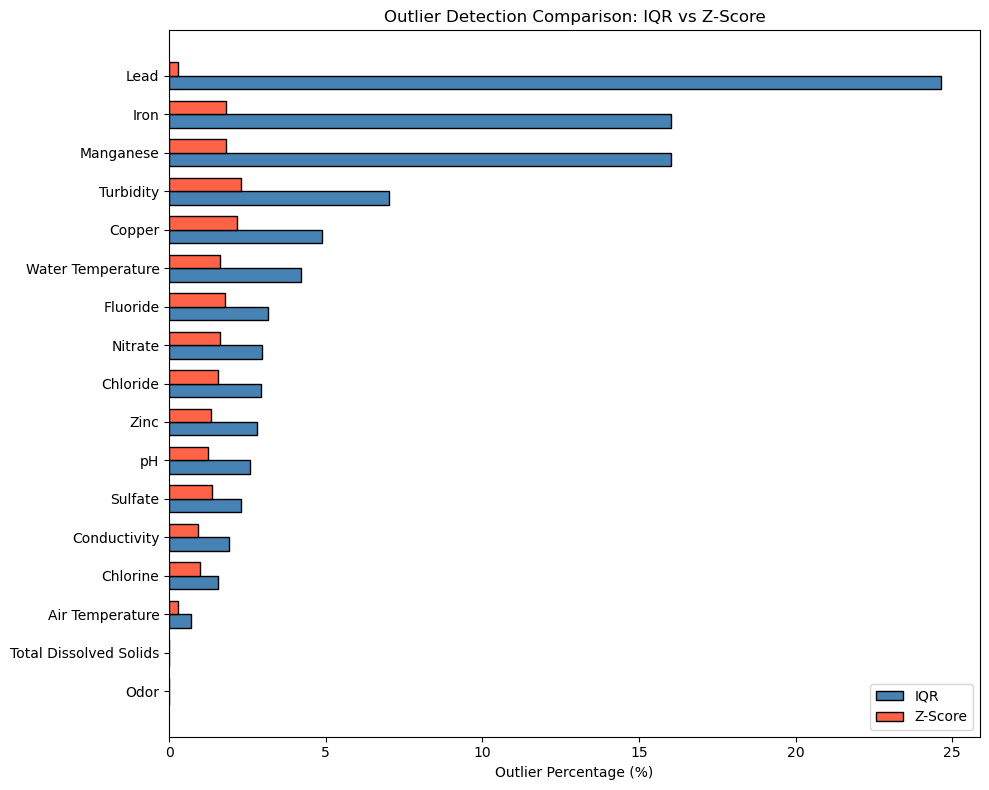

In [22]:
# Side-by-side comparison: IQR vs Z-Score outlier percentages
# Multiseries bar chart following the style in Ch.4 slides
compare_df = outlier_df[['Feature', 'Outlier %']].rename(columns={'Outlier %': 'IQR %'})
compare_df = compare_df.merge(
    zscore_df[['Feature', 'Outlier %']].rename(columns={'Outlier %': 'Z-Score %'}),
    on='Feature'
).sort_values('IQR %', ascending=True)

index  = np.arange(len(compare_df))
width  = 0.35

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(index,           compare_df['IQR %'],     width, label='IQR',     color='steelblue', edgecolor='black')
ax.barh(index + width,   compare_df['Z-Score %'], width, label='Z-Score', color='tomato',    edgecolor='black')

ax.set_yticks(index + width / 2)
ax.set_yticklabels(compare_df['Feature'])
ax.set_xlabel('Outlier Percentage (%)')
ax.set_title('Outlier Detection Comparison: IQR vs Z-Score')
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('../reports/figures/outlier_comparison.png', dpi=150)
plt.show()